In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

print("Pandas:", pd.__version__)
print("Seaborn:", sns.__version__)
print("Scikit-learn:", sklearn.__version__)

Pandas: 3.0.6
Seaborn: 0.13.2
Scikit-learn: 1.9.1


In [2]:
import pandas as pd
import seaborn as sns

# Load the Titanic dataset once
df = sns.load_dataset("titanic")

# Save a local offline fallback
df.to_csv("../titanic.csv", index=False)

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)

Titanic dataset loaded successfully.
Shape: (891, 15)


In [3]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

import pandas as pd

# Load the local cached Titanic dataset
df = pd.read_csv("../titanic.csv")

# Create cleaned dataset
df_clean = df.copy()

# Drop rows with missing embarked
df_clean = df_clean.dropna(subset=["embarked"])

# Impute missing age using the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Drop very-high-missing and redundant columns
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())

Cleaned dataset shape: (889, 13)
Total missing values: 0


In [4]:
print("===== DATASET INFO =====")
df.info()

print("\n===== DESCRIPTIVE STATISTICS =====")
print(df.describe())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== MISSING VALUES =====")
missing = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

print(missing_summary[missing_summary["missing_count"] > 0])

===== DATASET INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB

===== DESCRIPTIVE STATISTICS =====
         survived      pclass         age       sibsp       par

In [5]:
# Make a copy for the cleaned dataset
df_clean = df.copy()

# 1. Drop rows with very small amounts of missing data
df_clean = df_clean.dropna(subset=["embarked"])

# 2. Median-impute age
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# 3. Drop very-high-missing and redundant columns
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("===== CLEANED DATASET =====")
print("Shape:", df_clean.shape)

print("\n===== MISSING VALUES AFTER CLEANING =====")
print(df_clean.isnull().sum())

print("\nAge median used for imputation:", age_median)

===== CLEANED DATASET =====
Shape: (889, 13)

===== MISSING VALUES AFTER CLEANING =====
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

Age median used for imputation: 28.0


In [6]:
# Save the cleaned Titanic dataset for later analysis/modeling
df_clean.to_csv("../titanic_cleaned.csv", index=False)

print("Cleaned Titanic dataset saved.")
print("Shape:", df_clean.shape)

Cleaned Titanic dataset saved.
Shape: (889, 13)


In [7]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

# Start again from the original dataset
df_clean = df.copy()

# Remove rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Fill missing age values with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Drop columns with very high missing values / duplicate information
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (889, 13)

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


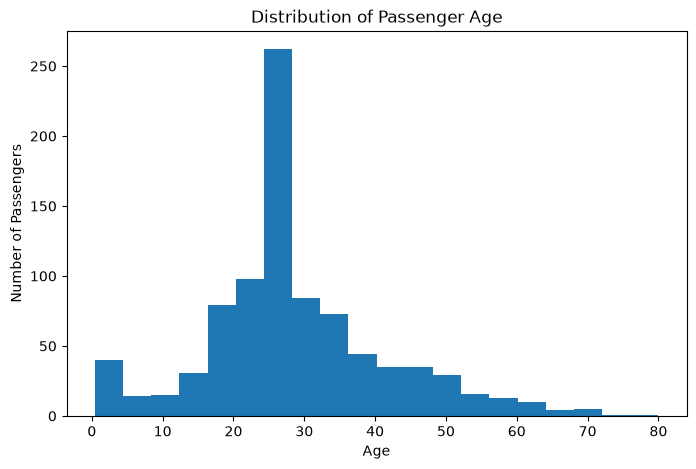

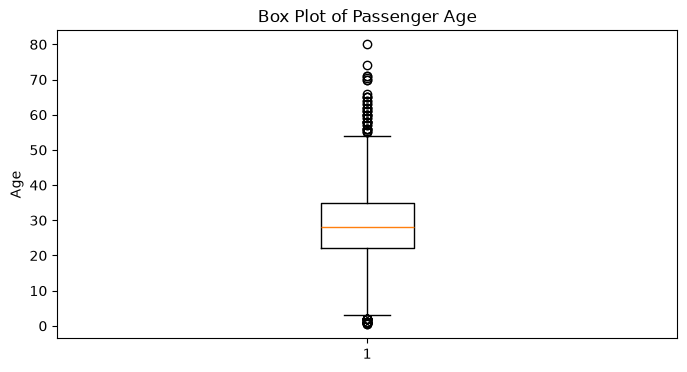

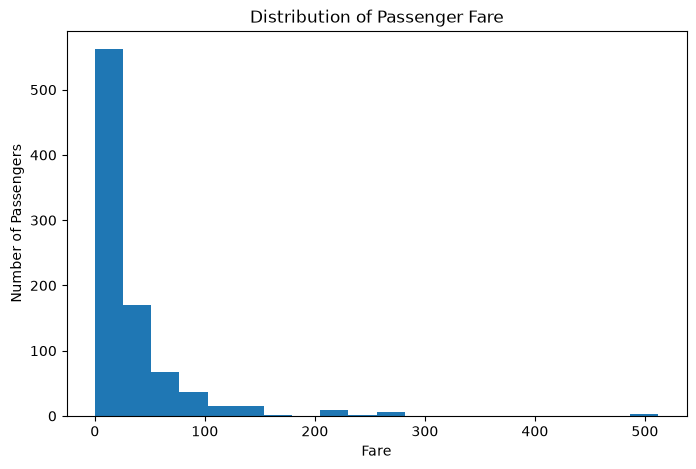

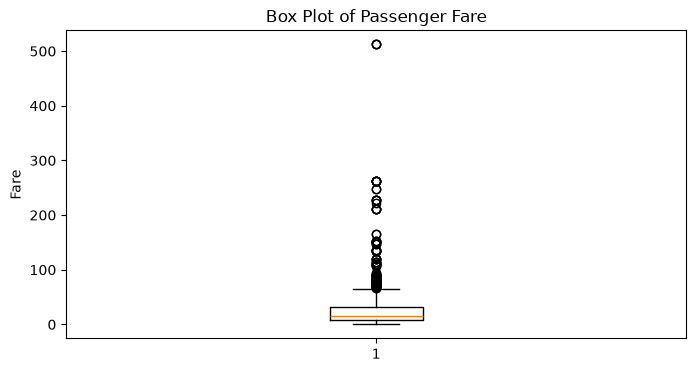

In [8]:
import matplotlib.pyplot as plt

# Age histogram
plt.figure(figsize=(8, 5))
plt.hist(df_clean["age"], bins=20)
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

# Age box plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean["age"])
plt.title("Box Plot of Passenger Age")
plt.ylabel("Age")
plt.show()

# Fare histogram
plt.figure(figsize=(8, 5))
plt.hist(df_clean["fare"], bins=20)
plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")
plt.show()

# Fare box plot
plt.figure(figsize=(8, 4))
plt.boxplot(df_clean["fare"])
plt.title("Box Plot of Passenger Fare")
plt.ylabel("Fare")
plt.show()

In [9]:
# -----------------------------
# IQR outlier calculation
# -----------------------------

def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return len(outliers), q1, q3, lower_bound, upper_bound


age_outliers, age_q1, age_q3, age_lower, age_upper = iqr_outlier_count(
    df_clean["age"]
)

fare_outliers, fare_q1, fare_q3, fare_lower, fare_upper = iqr_outlier_count(
    df_clean["fare"]
)

print("===== IQR OUTLIERS =====")

print("\nAge:")
print("Q1:", age_q1)
print("Q3:", age_q3)
print("IQR:", age_q3 - age_q1)
print("Lower bound:", age_lower)
print("Upper bound:", age_upper)
print("Outlier count:", age_outliers)

print("\nFare:")
print("Q1:", fare_q1)
print("Q3:", fare_q3)
print("IQR:", fare_q3 - fare_q1)
print("Lower bound:", fare_lower)
print("Upper bound:", fare_upper)
print("Outlier count:", fare_outliers)


# -----------------------------
# Fare statistics
# -----------------------------

fare_mean = df_clean["fare"].mean()
fare_median = df_clean["fare"].median()
fare_mode = df_clean["fare"].mode()[0]
fare_skewness = df_clean["fare"].skew()

print("\n===== FARE STATISTICS =====")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)
print("Skewness:", fare_skewness)

if fare_mean > fare_median:
    print("Interpretation: Fare is right-skewed because mean > median.")
elif fare_mean < fare_median:
    print("Interpretation: Fare is left-skewed because mean < median.")
else:
    print("Interpretation: Mean and median are approximately equal.")

===== IQR OUTLIERS =====

Age:
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower bound: 2.5
Upper bound: 54.5
Outlier count: 65

Fare:
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower bound: -26.7605
Upper bound: 65.6563
Outlier count: 114

===== FARE STATISTICS =====
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05
Skewness: 4.801440211044194
Interpretation: Fare is right-skewed because mean > median.


In [10]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

# Start again from the original dataset
df_clean = df.copy()

# Remove rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Fill missing age values with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Drop columns with very high missing values / duplicate information
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (889, 13)

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [11]:
# ==========================================
# BIVARIATE ANALYSIS
# ==========================================

# 1. Survival rate by sex
survival_by_sex = df_clean.groupby("sex")["survived"].mean()

print("===== SURVIVAL RATE BY SEX =====")
print(survival_by_sex)


# 2. Survival rate by passenger class
survival_by_pclass = df_clean.groupby("pclass")["survived"].mean()

print("\n===== SURVIVAL RATE BY PCLASS =====")
print(survival_by_pclass)


# 3. Survival rate by sex and passenger class
survival_by_sex_pclass = (
    df_clean.groupby(["sex", "pclass"])["survived"]
    .mean()
)

print("\n===== SURVIVAL RATE BY SEX + PCLASS =====")
print(survival_by_sex_pclass)


# 4. Boolean masking example
female_first_class = df_clean[
    (df_clean["sex"] == "female") &
    (df_clean["pclass"] == 1)
]

female_first_survival_rate = female_first_class["survived"].mean()

print("\n===== BOOLEAN MASKING =====")
print("Female passengers in 1st class:", len(female_first_class))
print("Their survival rate:", female_first_survival_rate)

===== SURVIVAL RATE BY SEX =====
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

===== SURVIVAL RATE BY PCLASS =====
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

===== SURVIVAL RATE BY SEX + PCLASS =====
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

===== BOOLEAN MASKING =====
Female passengers in 1st class: 92
Their survival rate: 0.967391304347826


### Bivariate Analysis Interpretation

The survival rate differs substantially by sex: female passengers had a survival rate of approximately 74.04%, compared with 18.89% for male passengers. Survival rate also decreased across passenger classes, from 62.62% in first class to 47.28% in second class and 24.24% in third class. When sex and passenger class are considered together, female first-class passengers had a survival rate of approximately 96.74%, while male third-class passengers had a survival rate of approximately 13.54%. These results show that sex and passenger class are important variables to examine when analyzing survival in this dataset.


In [12]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = df_clean[correlation_columns].corr()

print("===== CORRELATION MATRIX =====")
print(correlation_matrix)

===== CORRELATION MATRIX =====
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


In [13]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

# Start again from the original dataset
df_clean = df.copy()

# Remove rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Fill missing age values with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Drop columns with very high missing values / duplicate information
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (889, 13)

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


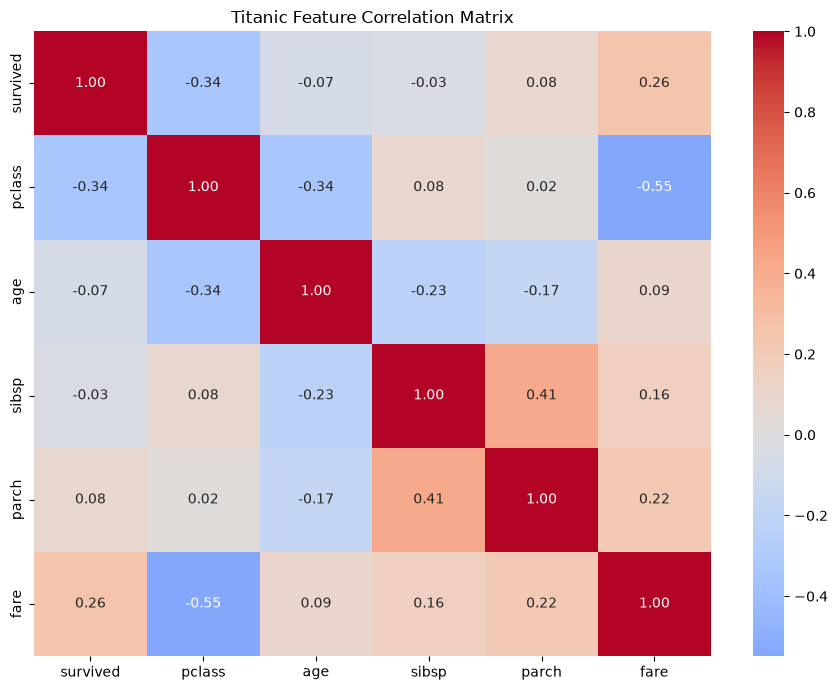

In [14]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Titanic Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### Correlation Analysis Interpretation

The strongest off-diagonal correlation is between `pclass` and `fare`, with a correlation of approximately **-0.55**, indicating a moderate negative relationship. This means that higher numerical passenger-class values, representing lower passenger classes, are generally associated with lower fares. The second strongest off-diagonal correlation is between `pclass` and `age`, with a correlation of approximately **-0.34**, indicating a moderate negative relationship between passenger class and age. Correlation measures association between variables and does not by itself establish causation.


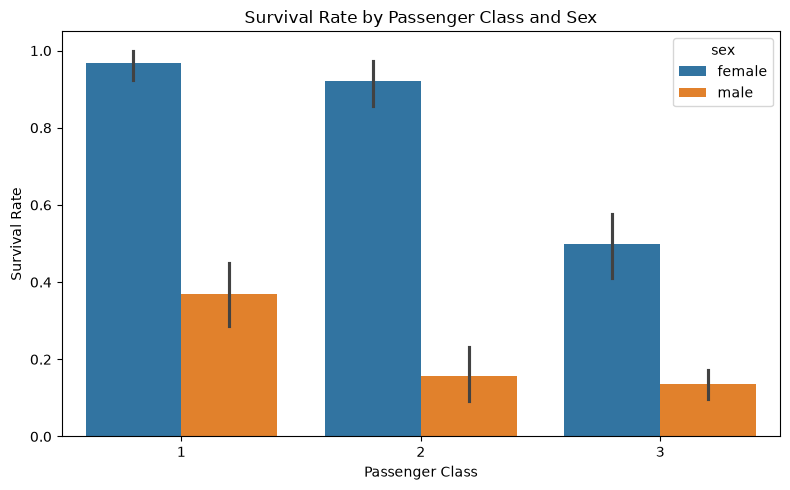

In [15]:
# ==========================================
# MULTIVARIATE CHART 1
# Survival by Sex and Passenger Class
# ==========================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.tight_layout()
plt.show()

### Interpretation

The chart shows that survival rates differed across both passenger class and sex. Female passengers had higher survival rates than male passengers within every passenger class. Survival was also generally higher in first class and lower in third class, showing that sex and passenger class together provide useful information about survival.


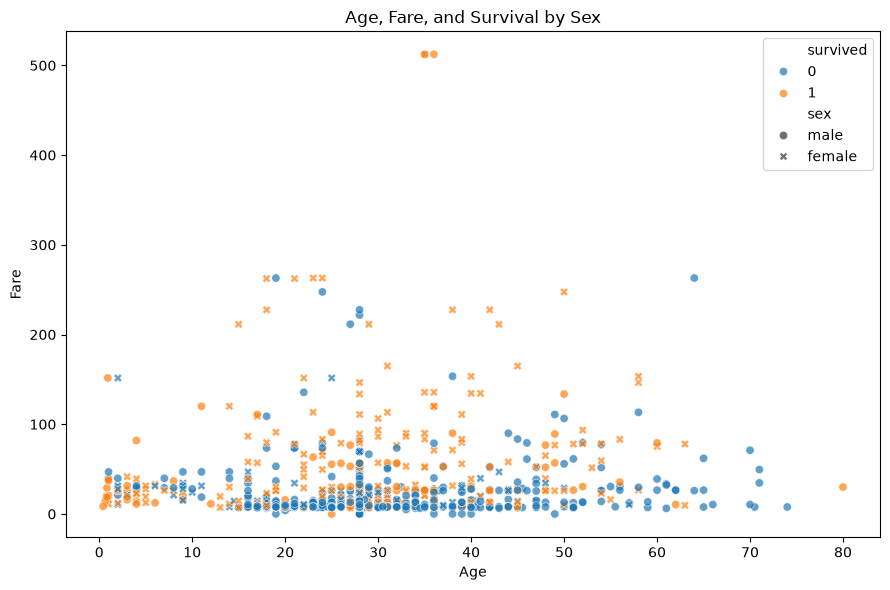

In [16]:
# ==========================================
# MULTIVARIATE CHART 2
# Age, Fare, and Survival
# ==========================================

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x="age",
    y="fare",
    hue="survived",
    style="sex",
    alpha=0.7
)

plt.title("Age, Fare, and Survival by Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

### Interpretation

The scatter plot shows the relationship between passenger age and fare while also distinguishing survival status and sex. Higher fares appear across a wide range of ages, although many of the higher-fare observations are associated with first-class passengers. The plot also shows that survival was not determined by age or fare alone, with different survival outcomes appearing across both variables and sexes.


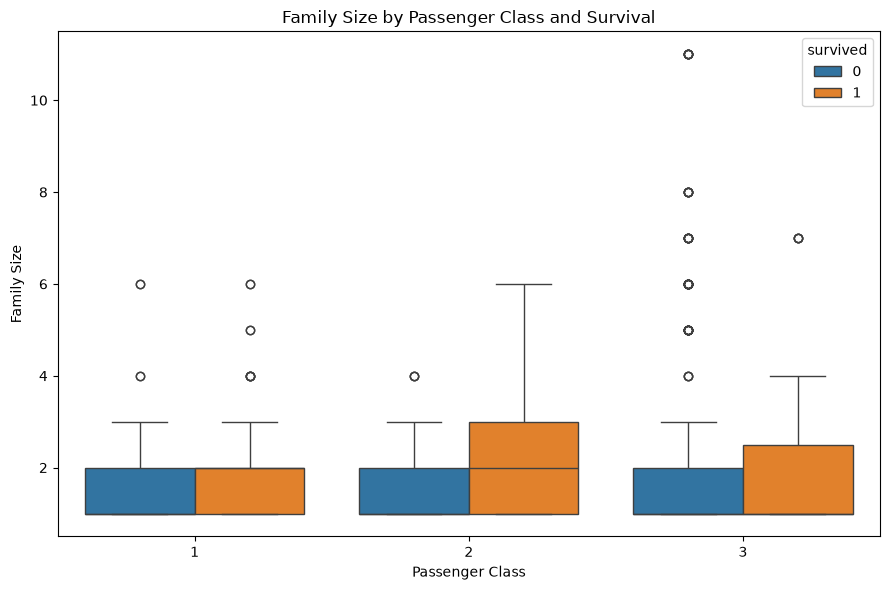

In [17]:
# ==========================================
# MULTIVARIATE CHART 3
# Family Size, Passenger Class, and Survival
# ==========================================

df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x="pclass",
    y="family_size",
    hue="survived"
)

plt.title("Family Size by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Family Size")
plt.tight_layout()
plt.show()

### Interpretation

The box plot compares family size across passenger classes and survival outcomes. Family-size distributions vary between passenger classes, showing that passenger class and family structure can be examined together when studying survival. The distributions also overlap between survivors and non-survivors, indicating that family size alone does not completely separate the two survival groups.


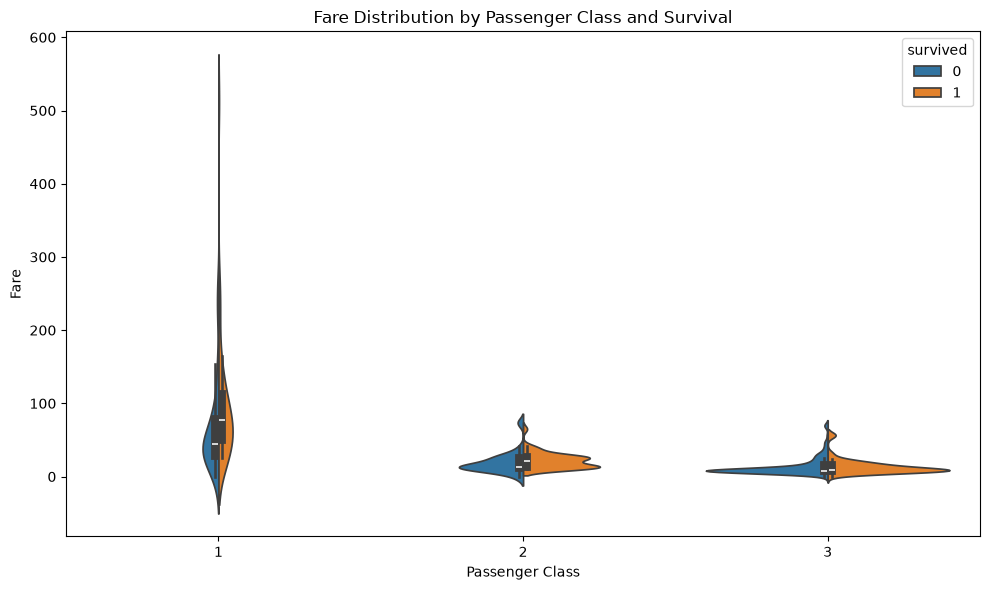

In [18]:
# ==========================================
# MULTIVARIATE CHART 4
# Fare, Passenger Class, and Survival
# ==========================================

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_clean,
    x="pclass",
    y="fare",
    hue="survived",
    split=True
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

### Interpretation

The violin plot shows how fare distributions differ across passenger classes and survival groups. First-class passengers generally have a wider and higher fare distribution than second- and third-class passengers. Within the classes, the fare distributions of survivors and non-survivors overlap, but the differences in distribution show that fare and passenger class are useful variables for examining survival patterns.


In [19]:
# ==========================================
# STANDARDIZATION FOR EDA
# ==========================================

# Select age and fare from the full cleaned dataset
eda_numeric = df_clean[["age", "fare"]].copy()

print("===== BEFORE STANDARDIZATION =====")
print(eda_numeric.agg(["mean", "std"]))


# Z-score standardization using pandas
eda_standardized = pd.DataFrame(index=df_clean.index)

eda_standardized["age_z"] = (
    (df_clean["age"] - df_clean["age"].mean())
    / df_clean["age"].std()
)

eda_standardized["fare_z"] = (
    (df_clean["fare"] - df_clean["fare"].mean())
    / df_clean["fare"].std()
)

print("\n===== AFTER STANDARDIZATION =====")
print(eda_standardized.agg(["mean", "std"]))

===== BEFORE STANDARDIZATION =====
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

===== AFTER STANDARDIZATION =====
             age_z        fare_z
mean  2.797412e-16  1.358743e-16
std   1.000000e+00  1.000000e+00


In [20]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

# Start again from the original dataset
df_clean = df.copy()

# Remove rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Fill missing age values with the median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Drop columns with very high missing values / duplicate information
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values:")
print(df_clean.isnull().sum())

Cleaned dataset shape: (889, 13)

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64


In [21]:
# ==========================================
# STANDARDIZATION FOR EDA
# ==========================================

# Select age and fare
eda_numeric = df_clean[["age", "fare"]].copy()

print("===== BEFORE STANDARDIZATION =====")
print(eda_numeric.agg(["mean", "std"]))

# Z-score standardization using pandas
eda_standardized = pd.DataFrame(index=df_clean.index)

eda_standardized["age_z"] = (
    (df_clean["age"] - df_clean["age"].mean())
    / df_clean["age"].std()
)

eda_standardized["fare_z"] = (
    (df_clean["fare"] - df_clean["fare"].mean())
    / df_clean["fare"].std()
)

print("\n===== AFTER STANDARDIZATION =====")
print(eda_standardized.agg(["mean", "std"]))

===== BEFORE STANDARDIZATION =====
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

===== AFTER STANDARDIZATION =====
             age_z        fare_z
mean  2.797412e-16  1.358743e-16
std   1.000000e+00  1.000000e+00


### Standardization Interpretation

Age and fare were standardized using z-score standardization on the full cleaned dataset for EDA purposes. Before standardization, age had a mean of approximately 29.32 and a standard deviation of 12.98, while fare had a mean of approximately 32.10 and a standard deviation of 49.70. After standardization, both variables had means extremely close to 0 and standard deviations equal to 1. This transformation puts age and fare on a common scale for exploratory analysis and does not feed the standardized values into the machine-learning models.


In [22]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\dnars\OneDrive\Desktop\zepto-data-ai-platform\.venv\Scripts\python.exe

Python version:
3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


In [23]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\dnars\OneDrive\Desktop\zepto-data-ai-platform\.venv\Scripts\python.exe

Python version:
3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


In [24]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.1


In [25]:
# ==========================================
# RECREATE CLEANED TITANIC DATASET
# ==========================================

import pandas as pd

# Load Titanic dataset from the analytics folder
df = pd.read_csv("../titanic.csv")

# Create a copy for cleaning
df_clean = df.copy()

# Remove rows where embarked is missing
df_clean = df_clean.dropna(subset=["embarked"])

# Fill missing age values with median
age_median = df_clean["age"].median()
df_clean["age"] = df_clean["age"].fillna(age_median)

# Remove columns with too many missing values / redundant information
df_clean = df_clean.drop(columns=["deck", "embark_town"])

print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nAge median used:", age_median)

Cleaned dataset shape: (889, 13)

Missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

Age median used: 28.0


In [26]:
# ==========================================
# STANDARDIZATION FOR EDA
# ==========================================

from sklearn.preprocessing import StandardScaler

# Select numeric columns
eda_numeric = df_clean[["age", "fare"]].copy()

print("===== BEFORE STANDARDIZATION =====")
print(eda_numeric.agg(["mean", "std"]))

# Create StandardScaler
scaler = StandardScaler()

# Standardize age and fare
eda_standardized = pd.DataFrame(
    scaler.fit_transform(eda_numeric),
    columns=["age_z", "fare_z"],
    index=df_clean.index
)

print("\n===== AFTER STANDARDIZATION =====")
print(eda_standardized.agg(["mean", "std"]))

===== BEFORE STANDARDIZATION =====
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

===== AFTER STANDARDIZATION =====
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


In [27]:
# ==========================================
# TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# Features
X = df_clean[["age", "fare"]]

# Target
y = df_clean["survived"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== TRAIN / TEST SPLIT =====")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

===== TRAIN / TEST SPLIT =====
X_train shape: (711, 2)
X_test shape: (178, 2)
y_train shape: (711,)
y_test shape: (178,)

Training samples: 711
Testing samples: 178


In [28]:
# ==========================================
# PREPARE FEATURES FOR ML
# ==========================================

# Target
y = df_clean["survived"]

# Features required for modeling
X = df_clean[
    [
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "fare",
        "embarked"
    ]
].copy()

print("Features:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("\nTarget shape:", y.shape)
print("\nMissing values in features:")
print(X.isnull().sum())

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Feature shape: (889, 7)

Target shape: (889,)

Missing values in features:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [29]:
# ==========================================
# PROPER ML TRAIN / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== ML TRAIN / TEST SPLIT =====")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining survival distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting survival distribution:")
print(y_test.value_counts(normalize=True))

===== ML TRAIN / TEST SPLIT =====
X_train shape: (711, 7)
X_test shape: (178, 7)
y_train shape: (711,)
y_test shape: (178,)

Training survival distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing survival distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


In [30]:
# ==========================================
# PREPROCESSING PIPELINE
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric and categorical feature lists
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline created successfully.

Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked']


In [31]:
# ==========================================
# CREATE CLASSIFICATION MODEL PIPELINES
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Decision Tree pipeline
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

# Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

print("Three classification pipelines created successfully.")

print("\n1. Logistic Regression")
print("2. Decision Tree")
print("3. Random Forest")

Three classification pipelines created successfully.

1. Logistic Regression
2. Decision Tree
3. Random Forest


In [32]:
# ==========================================
# TRAIN THE THREE CLASSIFICATION MODELS
# ==========================================

print("Training Logistic Regression...")
logistic_pipeline.fit(X_train, y_train)

print("Training Decision Tree...")
decision_tree_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_pipeline.fit(X_train, y_train)

print("\nAll three models trained successfully.")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All three models trained successfully.


In [33]:
# ==========================================
# EVALUATE THE THREE CLASSIFIERS
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Store models in a dictionary
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for model_name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for positive class
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

# Create comparison table
classification_results = pd.DataFrame(results)

print("===== CLASSIFICATION MODEL COMPARISON =====")
print(classification_results.round(4))

===== CLASSIFICATION MODEL COMPARISON =====
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344   0.8610
1        Decision Tree    0.7697     0.6901  0.7206  0.7050   0.7541
2        Random Forest    0.8202     0.7812  0.7353  0.7576   0.8179


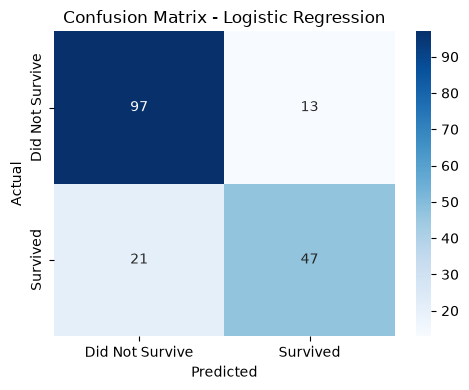

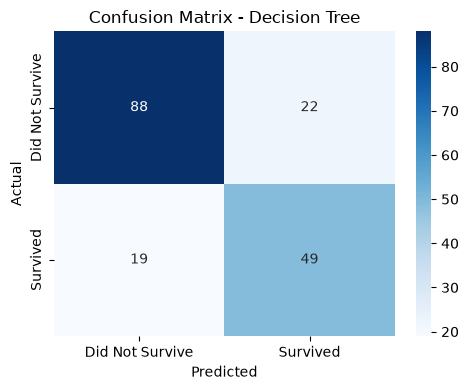

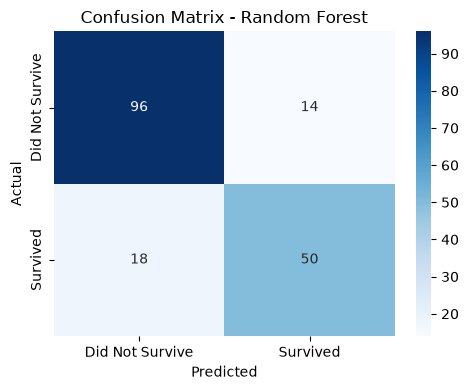

In [34]:
# ==========================================
# CONFUSION MATRICES FOR ALL CLASSIFIERS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for model_name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Did Not Survive", "Survived"],
        yticklabels=["Did Not Survive", "Survived"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

Number of transformed features: 10

Feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


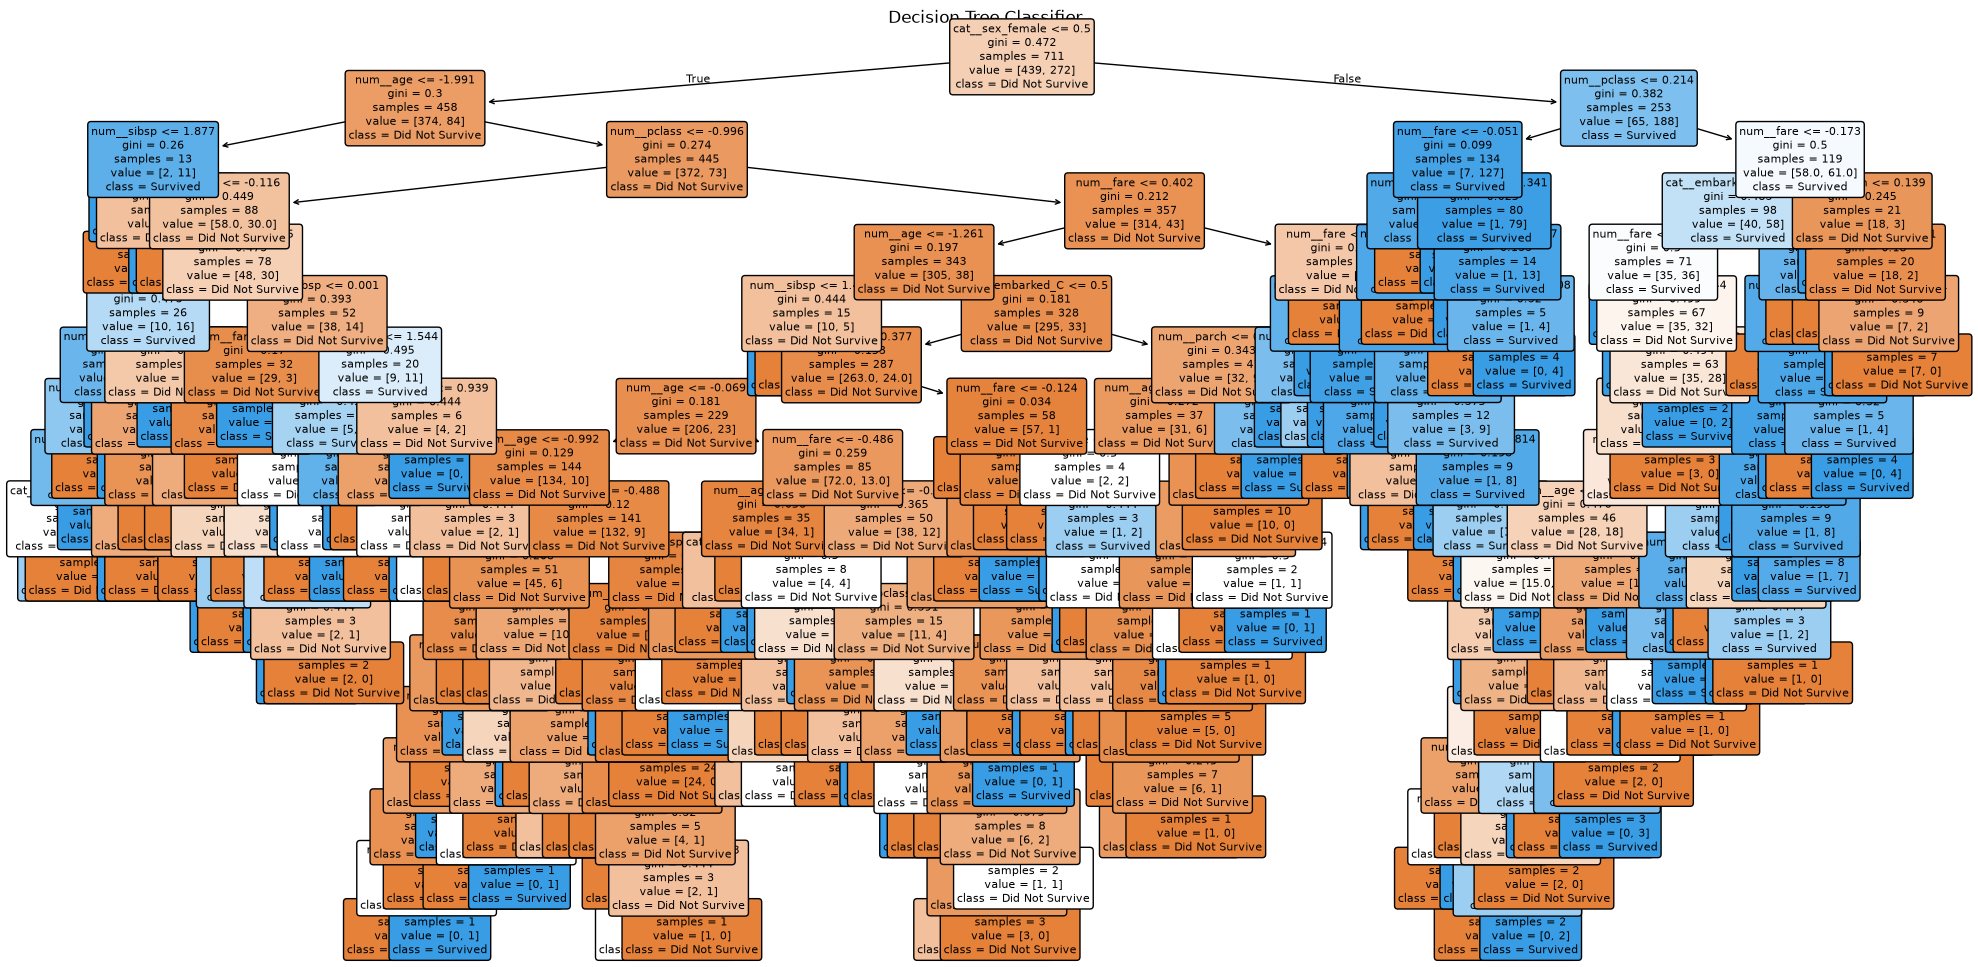

In [35]:
# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

from sklearn.tree import plot_tree

# Get the fitted preprocessor
fitted_preprocessor = decision_tree_pipeline.named_steps["preprocessor"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get the trained Decision Tree
decision_tree_model = decision_tree_pipeline.named_steps["model"]

print("Number of transformed features:", len(feature_names))
print("\nFeature names:")
print(feature_names)

# Plot the decision tree
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=["Did Not Survive", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Classifier")
plt.show()

In [36]:
# ==========================================
# IMBALANCE HANDLING PIPELINES
# ==========================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# 1. Baseline Logistic Regression
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# 2. Class-weight balanced Logistic Regression
balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# 3. SMOTE Logistic Regression
smote_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

print("Three imbalance-handling pipelines created successfully.")
print("\n1. Baseline")
print("2. Class Weight = Balanced")
print("3. SMOTE")

Three imbalance-handling pipelines created successfully.

1. Baseline
2. Class Weight = Balanced
3. SMOTE


In [37]:
# ==========================================
# TRAIN IMBALANCE-HANDLING MODELS
# ==========================================

print("Training Baseline Logistic Regression...")
baseline_pipeline.fit(X_train, y_train)

print("Training Class-Weight Balanced Logistic Regression...")
balanced_pipeline.fit(X_train, y_train)

print("Training SMOTE Logistic Regression...")
smote_pipeline.fit(X_train, y_train)

print("\nAll three imbalance-handling models trained successfully.")

Training Baseline Logistic Regression...
Training Class-Weight Balanced Logistic Regression...
Training SMOTE Logistic Regression...

All three imbalance-handling models trained successfully.


In [38]:
# ==========================================
# COMPARE IMBALANCE-HANDLING METHODS
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score

imbalance_models = {
    "Baseline": baseline_pipeline,
    "Class Weight Balanced": balanced_pipeline,
    "SMOTE": smote_pipeline
}

imbalance_results = []

for method_name, model in imbalance_models.items():

    y_pred = model.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    imbalance_results.append({
        "Method": method_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

imbalance_comparison = pd.DataFrame(imbalance_results)

print("===== IMBALANCE HANDLING COMPARISON =====")
print(imbalance_comparison.round(4))

===== IMBALANCE HANDLING COMPARISON =====
                  Method  Precision  Recall      F1
0               Baseline     0.7833  0.6912  0.7344
1  Class Weight Balanced     0.7183  0.7500  0.7338
2                  SMOTE     0.7353  0.7353  0.7353


The baseline Logistic Regression model achieved a precision of 0.7833, recall of 0.6912, and F1-score of 0.7344. Using `class_weight="balanced"` increased recall to 0.7500 but reduced precision to 0.7183, showing a trade-off between identifying more positive cases and making fewer positive predictions correctly. SMOTE produced a precision of 0.7353, recall of 0.7353, and F1-score of 0.7353. Overall, the three approaches produced very similar F1-scores, while the balanced approach placed relatively more emphasis on recall.


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest estimator
rf_estimator = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

# Put preprocessing + Random Forest together
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_estimator)
    ]
)

# Parameter grid
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train GridSearchCV on training data only
grid_search.fit(X_train, y_train)

print("===== GRID SEARCH RESULTS =====")
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

# Get the best fitted Random Forest
best_rf_pipeline = grid_search.best_estimator_

# Get OOB score from the fitted Random Forest
best_rf_model = best_rf_pipeline.named_steps["model"]

print("\nOOB Score:")
print(round(best_rf_model.oob_score_, 4))

===== GRID SEARCH RESULTS =====
Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7408

OOB Score:
0.8214


In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Predictions from the tuned Random Forest
y_pred_best_rf = best_rf_pipeline.predict(X_test)
y_prob_best_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]

# Calculate test-set metrics
best_rf_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_best_rf),
    "Precision": precision_score(y_test, y_pred_best_rf),
    "Recall": recall_score(y_test, y_pred_best_rf),
    "F1": f1_score(y_test, y_pred_best_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_best_rf)
}

best_rf_results_df = pd.DataFrame([best_rf_results])

print("===== TUNED RANDOM FOREST TEST RESULTS =====")
print(best_rf_results_df.round(4))

===== TUNED RANDOM FOREST TEST RESULTS =====
                 Model  Accuracy  Precision  Recall    F1  ROC-AUC
0  Tuned Random Forest    0.8315     0.8654  0.6618  0.75   0.8389


In [41]:
# Prepare regression features and target

regression_target = df_clean["fare"]

regression_features = df_clean[
    [
        "survived",
        "pclass",
        "sex",
        "age",
        "sibsp",
        "parch",
        "embarked"
    ]
].copy()

print("Regression features:")
print(regression_features.columns.tolist())

print("\nRegression feature shape:", regression_features.shape)
print("Regression target shape:", regression_target.shape)

print("\nMissing values:")
print(regression_features.isnull().sum())

Regression features:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'embarked']

Regression feature shape: (889, 7)
Regression target shape: (889,)

Missing values:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
embarked    0
dtype: int64


In [42]:
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    regression_features,
    regression_target,
    test_size=0.20,
    random_state=42
)

print("===== REGRESSION TRAIN/TEST SPLIT =====")
print("X_train shape:", X_reg_train.shape)
print("X_test shape:", X_reg_test.shape)
print("y_train shape:", y_reg_train.shape)
print("y_test shape:", y_reg_test.shape)

===== REGRESSION TRAIN/TEST SPLIT =====
X_train shape: (711, 7)
X_test shape: (178, 7)
y_train shape: (711,)
y_test shape: (178,)


In [43]:
from sklearn.linear_model import LinearRegression

# Regression feature groups
reg_numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

# Numeric preprocessing
reg_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing
reg_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

# Complete regression pipeline
regression_pipeline = Pipeline(
    steps=[
        ("preprocessor", reg_preprocessor),
        ("model", LinearRegression())
    ]
)

print("Regression pipeline created successfully.")

Regression pipeline created successfully.


In [44]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Train the regression model
regression_pipeline.fit(X_reg_train, y_reg_train)

# Predict fare on the test set
y_reg_pred = regression_pipeline.predict(X_reg_test)

# Calculate regression metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

# Number of observations and predictors
n = len(y_reg_test)

reg_preprocessor_fitted = regression_pipeline.named_steps["preprocessor"]
X_reg_test_transformed = reg_preprocessor_fitted.transform(X_reg_test)

p = X_reg_test_transformed.shape[1]

# Adjusted R-squared
adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("===== REGRESSION RESULTS =====")
print("MAE:", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²:", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))
print("Number of test observations (n):", n)
print("Number of transformed predictors (p):", p)

===== REGRESSION RESULTS =====
MAE: 21.0986
RMSE: 41.7021
R²: 0.3482
Adjusted R²: 0.3091
Number of test observations (n): 178
Number of transformed predictors (p): 10


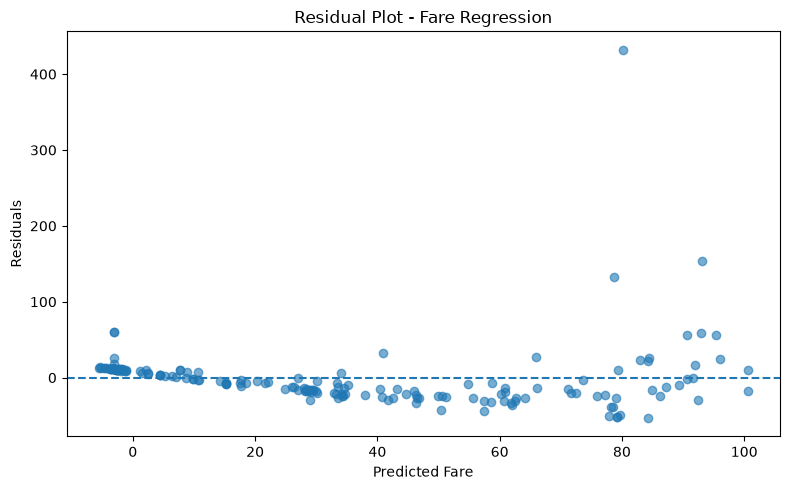

In [45]:
# Calculate residuals
residuals = y_reg_test - y_reg_pred

# Residual plot
plt.figure(figsize=(8, 5))

plt.scatter(
    y_reg_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot - Fare Regression")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

The residual plot shows that the residuals are randomly scattered around zero without a clear funnel-shaped pattern. This suggests that there is no strong visual evidence of heteroscedasticity in the test-set residuals. The regression model has an MAE of 21.10, RMSE of 41.70, R² of 0.3482, and adjusted R² of 0.3091. The relatively large difference between RMSE and MAE also indicates that some predictions have larger errors than the typical absolute error.


In [46]:
# Final classifier comparison
final_classifier_results = classification_results.copy()

# Add tuned Random Forest results
final_classifier_results = pd.concat(
    [
        final_classifier_results,
        best_rf_results_df
    ],
    ignore_index=True
)

print("===== FINAL CLASSIFIER COMPARISON =====")
print(final_classifier_results.round(4))

# Regression results as a separate group
final_regression_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2,
        "Adjusted R²": adjusted_r2
    }
])

print("\n===== REGRESSION RESULTS =====")
print(final_regression_results.round(4))

===== FINAL CLASSIFIER COMPARISON =====
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344   0.8610
1        Decision Tree    0.7697     0.6901  0.7206  0.7050   0.7541
2        Random Forest    0.8202     0.7812  0.7353  0.7576   0.8179
3  Tuned Random Forest    0.8315     0.8654  0.6618  0.7500   0.8389

===== REGRESSION RESULTS =====
               Model      MAE     RMSE      R²  Adjusted R²
0  Linear Regression  21.0986  41.7021  0.3482       0.3091


Among the evaluated classifiers, the tuned Random Forest achieved the highest test accuracy of 0.8315 and precision of 0.8654, with an F1-score of 0.7500 and ROC-AUC of 0.8389. The original Random Forest achieved an F1-score of 0.7576, while Logistic Regression achieved a ROC-AUC of 0.8610. Therefore, based on the overall test-set metrics and the project requirement to compare multiple classifiers, the Random Forest models provide a strong choice for the final Titanic survival classification task, with the tuned model offering improved accuracy and precision. The Linear Regression fare model achieved an R² of 0.3482 and adjusted R² of 0.3091, indicating that the available passenger features explain part, but not all, of the variation in fare.
